Scrivere il problema di Empirical Risk Minimization per una regressione lineare sui seguenti dati, utilizzando la Squared Error Loss

| OBJECT ID | FEAT 1 | FEAT 2 | LABEL |
|-|-|-|-|
| a | 0 | 10 | 2 |
| b | -1 | 9 | 0.5 |
| c | 0 | 0 | 0 |
| d | 98 | 99 | 100 |

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from sklearn.linear_model import LinearRegression


In [4]:
X = np.array([
    [0, 10],
    [-1, 9],
    [0, 0],
    [98, 99]
])

y = np.array([2, 0.5, 0, 100])

In [5]:
model = LinearRegression()
model.fit(X, y)

w_model = model.coef_
print(f"Coefficenti: {w_model}")



Coefficenti: [0.84251683 0.17614156]


In [8]:
w_analytical = np.linalg.inv(X.T @ X) @ X.T @ y
print("Pesi analitici:", w_analytical)


print("Differenza:", w_analytical - w_model)

y_pred = X @ w_analytical
loss = np.mean((y - y_pred) ** 2)

print("Predizioni:", y_pred)
print("MSE:", loss)

Pesi analitici: [0.84271848 0.17591963]
Differenza: [ 0.00020165 -0.00022193]
Predizioni: [  1.75919632   0.74055821   0.         100.00245468]
MSE: 0.02896517220953568


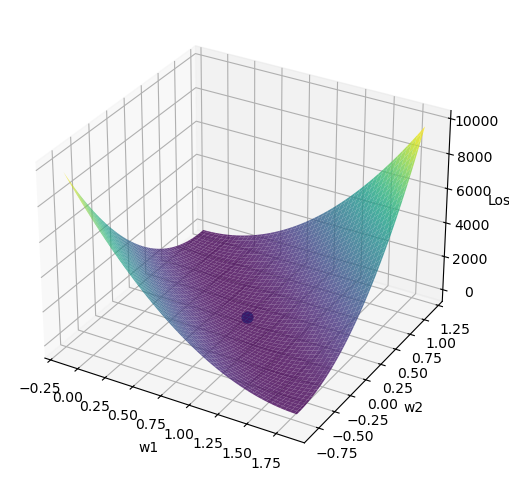

In [10]:
w1_vals = np.linspace(w_analytical[0] - 1, w_analytical[0] + 1, 100)
w2_vals = np.linspace(w_analytical[1] - 1, w_analytical[1] + 1, 100)
W1, W2 = np.meshgrid(w1_vals, w2_vals)

loss_grid = np.zeros_like(W1)

for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w = np.array([W1[i, j], W2[i, j]])
        y_pred_grid = X @ w
        loss_grid[i, j] = np.mean((y - y_pred_grid) ** 2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, loss_grid, cmap='viridis', alpha=0.8)
ax.scatter(w_analytical[0], w_analytical[1], np.mean((y - X @ w_analytical) ** 2), s=60)
ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Loss")
plt.show()